In [7]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

df = pd.read_csv("../day02-python-problems/cleaned_titanic.csv")
features = ["Pclass", "Sex", "Age", "Fare", "Embarked", "FamilySize", "IsAlone"]
X = df[features]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

baseline_tree = DecisionTreeClassifier(random_state=42)
baseline_tree.fit(X_train, y_train)

train_acc = accuracy_score(y_train, baseline_tree.predict(X_train))
test_acc = accuracy_score(y_test, baseline_tree.predict(X_test))

print(f"Baseline Tree → Training Accuracy: {round(train_acc * 100, 2)} %")
print(f"Baseline Tree → Test Accuracy: {round(test_acc * 100, 2)} %")

tuned_tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=10,
    random_state=42
)
tuned_tree.fit(X_train, y_train)

train_acc = accuracy_score(y_train, tuned_tree.predict(X_train))
test_acc = accuracy_score(y_test, tuned_tree.predict(X_test))

print(f"Tuned Tree → Training Accuracy: {round(train_acc * 100, 2)} %")
print(f"Tuned Tree → Test Accuracy: {round(test_acc * 100, 2)} %")



Baseline Tree → Training Accuracy: 98.03 %
Baseline Tree → Test Accuracy: 78.21 %
Tuned Tree → Training Accuracy: 83.85 %
Tuned Tree → Test Accuracy: 79.89 %


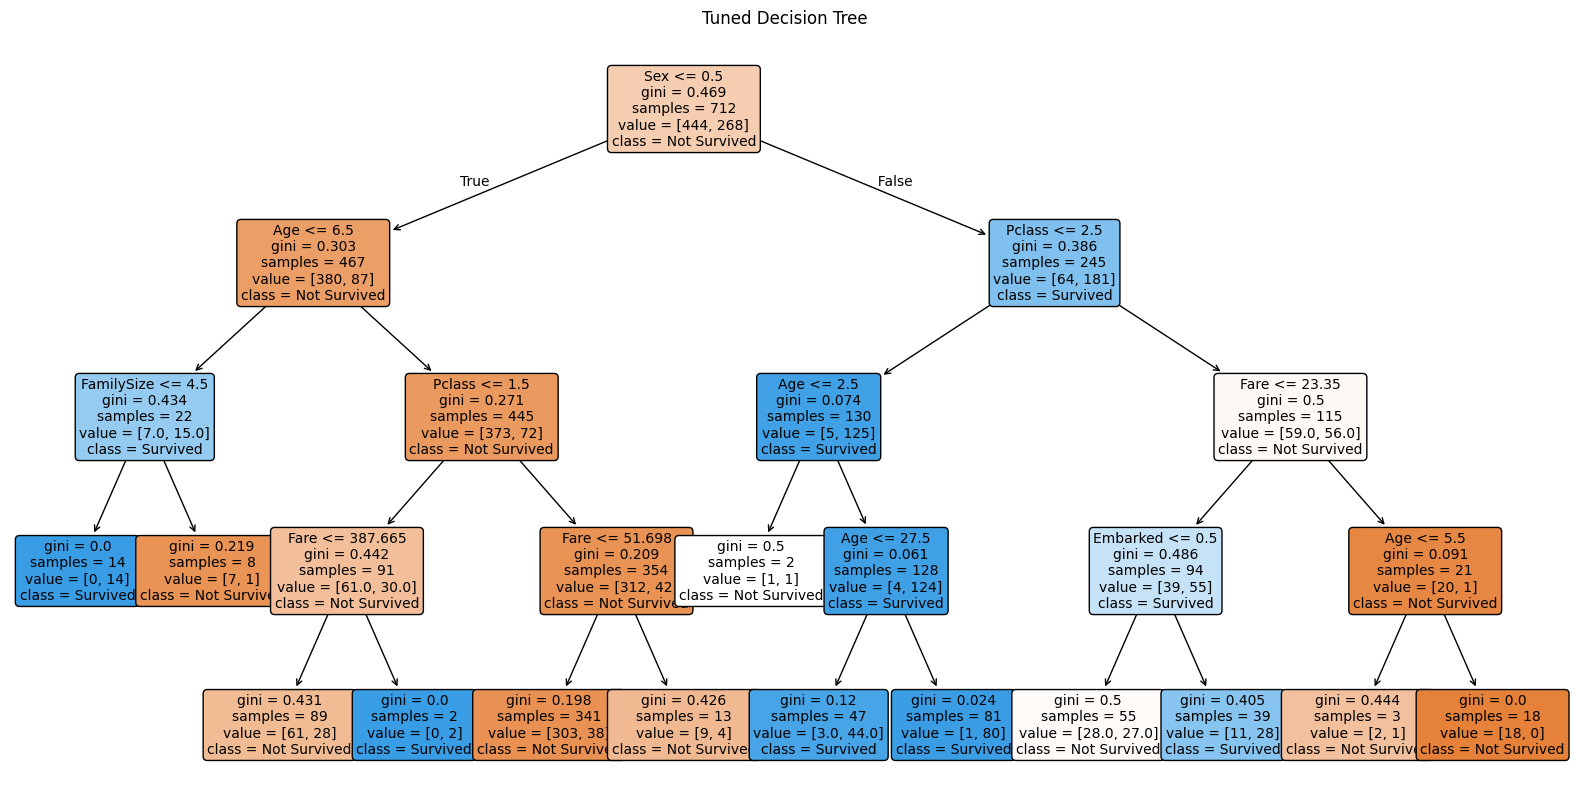

In [6]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(
    tuned_tree, 
    feature_names=X.columns, 
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Tuned Decision Tree")
plt.show()
